# Evaluation RAG - LogiStore

Evaluation systematique du moteur de recherche de tickets.

| Etape | Objectif | Metrique | Cout |
|-------|----------|----------|------|
| 1. Screening large | Quelle methode/filtre ? | Hit@K / MRR | 0 |
| 2. Battle Embedding | E5 ou MiniLM ? | Hit@K / MRR | 0 |
| 3. Fenetre de tir (K) | Combien de chunks ? | Hit@K (K=3,5,7,10) | 0 |
| 4. RAGAS Baseline | Qualite brute des contextes | Context Precision / Recall | LLM |
| 5. Reranking | ColBERT nettoie-t-il le bruit ? | RAGAS vs Baseline | LLM |
| 6. Robustesse | Le juge est-il fiable ? | Variance inter-juges | LLM |

## 1. Setup

In [25]:
import os, sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
sys.path.append(os.path.abspath("../app"))
sys.path.append(os.path.abspath("."))

from rag_engine import search
from eval_utils import (
    collect_results, collect_with_case_filter, collect_all_configs,
    hit_at_1, hit_at_k, mrr, compute_hitk_table,
    make_openrouter_client, make_judge, run_ragas, run_ragas_multi_judge,
    ragas_summary, judge_correlations,
    SCORE_COLS, METHODS, FILTER_MODES,
)

print("Setup OK")

Setup OK


### 1b. Jeux de test

- **Large** (384 samples, 32/strate) : etapes 1-4 (gratuit, Hit@K/MRR) — marge ±5%, confiance 95%
- **Small** (180 samples, 15/strate) : etapes 5-7 (RAGAS, cout LLM) — marge ~±7%, ~$1

In [26]:
df = pd.read_csv("../data/processed/tickets_clean.csv")
df_en = df[(df["language"] == "en") & (df["subject"].notna()) & (df["answer"].notna())].copy()

# --- Large test set : 32 par strate = 384 samples (etapes 1-4, gratuit) ---
# Justification : marge d'erreur ±5% a 95% de confiance (N=13729)
df_large = (
    df_en.groupby(["type", "priority"])
    .sample(n=32, random_state=42)
    .reset_index(drop=True)
)

test_cases_large = []
for _, row in df_large.iterrows():
    test_cases_large.append({
        "query": row["subject"],
        "reference": row["answer"],
        "type": row["type"],
        "priority": row["priority"],
        "queue": row["queue"],
    })

# --- Small test set : 15 par strate = 180 samples (etapes 5-7, RAGAS) ---
# Justification : marge ~±7% a 95% de confiance, cout ~$1
df_small = (
    df_en.groupby(["type", "priority"])
    .sample(n=15, random_state=42)
    .reset_index(drop=True)
)

test_cases_small = []
for _, row in df_small.iterrows():
    test_cases_small.append({
        "query": row["subject"],
        "reference": row["answer"],
        "type": row["type"],
        "priority": row["priority"],
        "queue": row["queue"],
    })

print(f"Test set LARGE : {len(test_cases_large)} samples (etapes 1-4)")
print(f"Test set SMALL : {len(test_cases_small)} samples (etapes 5-7)")
print(f"\nRepartition LARGE :")
print(df_large.groupby(["type", "priority"]).size().unstack(fill_value=0))

Test set LARGE : 384 samples (etapes 1-4)
Test set SMALL : 180 samples (etapes 5-7)

Repartition LARGE :
priority  high  low  medium
type                       
Change      32   32      32
Incident    32   32      32
Problem     32   32      32
Request     32   32      32


---
## 2. Screening large (12 configs)

### 2a. Collecte + calcul

In [27]:
# Collecte 12 configs : 3 methodes x 4 filtres (collection par defaut = MiniLM)
print(f"=== COLLECTE 12 CONFIGS (K=3, {len(test_cases_large)} samples) ===")
all_raw = collect_all_configs(search, test_cases_large, limit=3)
print(f"\n{len(all_raw)} configurations collectees")

# Calcul Hit@1 / MRR
df_hitk = compute_hitk_table(all_raw)
display(df_hitk.style.format({"hit_at_1": "{:.3f}", "hit_at_k": "{:.3f}", "mrr": "{:.3f}"}))

=== COLLECTE 12 CONFIGS (K=3, 384 samples) ===
  dense / no_filter ...
  dense / type_filter ...
  dense / priority_filter ...
  dense / queue_filter ...
  sparse / no_filter ...
  sparse / type_filter ...
  sparse / priority_filter ...
  sparse / queue_filter ...
  hybrid / no_filter ...
  hybrid / type_filter ...
  hybrid / priority_filter ...
  hybrid / queue_filter ...

12 configurations collectees


,method,filter,hit_at_1,hit_at_k,mrr
0,hybrid,queue_filter,0.672,0.672,0.672
1,sparse,queue_filter,0.651,0.651,0.651
2,hybrid,priority_filter,0.625,0.625,0.625
3,sparse,priority_filter,0.609,0.609,0.609
4,hybrid,type_filter,0.599,0.599,0.599
5,sparse,type_filter,0.568,0.568,0.568
6,dense,queue_filter,0.562,0.562,0.562
7,hybrid,no_filter,0.547,0.547,0.547
8,sparse,no_filter,0.505,0.505,0.505
9,dense,priority_filter,0.492,0.492,0.492


### 2b. Visualisation

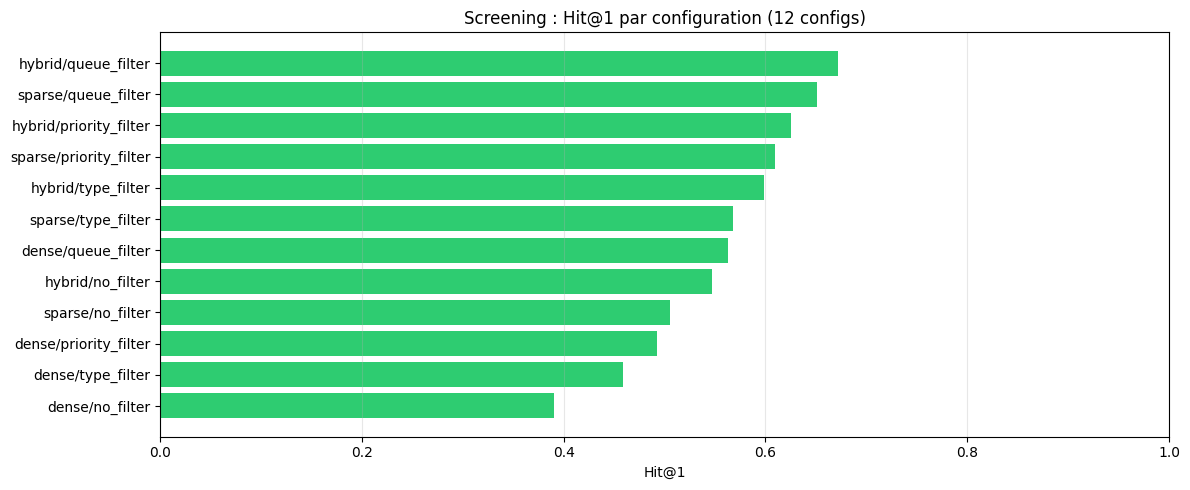


TOP 3 :


,method,filter,hit_at_1,hit_at_k,mrr
0,hybrid,queue_filter,0.671875,0.671875,0.671875
1,sparse,queue_filter,0.651042,0.651042,0.651042
2,hybrid,priority_filter,0.625000,0.625000,0.625000


In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
df_sorted = df_hitk.sort_values("hit_at_1", ascending=True)
labels = [f"{r['method']}/{r['filter']}" for _, r in df_sorted.iterrows()]
colors = ["#2ecc71" if v > 0.3 else "#e74c3c" if v < 0.1 else "#f39c12" for v in df_sorted["hit_at_1"]]

ax.barh(range(len(labels)), df_sorted["hit_at_1"], color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Hit@1")
ax.set_title("Screening : Hit@1 par configuration (12 configs)")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTOP 3 :")
display(df_hitk.head(3))

---
## 3. Battle Embedding : E5 vs MiniLM

### 3a. Collecte + calcul

In [29]:
# On compare sur la meilleure methode/filtre identifiee en section 2
best_method = df_hitk.iloc[0]["method"]
best_filter = df_hitk.iloc[0]["filter"]
print(f"Config de reference : {best_method} / {best_filter}")

COLLECTIONS = {"MiniLM": "tickets", "E5": "tickets_e5"}
emb_results = {}

for model_name, col_name in COLLECTIONS.items():
    print(f"\n  {model_name} ({col_name}) ...")
    if best_filter == "no_filter":
        emb_results[model_name] = collect_results(
            search, test_cases_large, method=best_method, limit=3, collection=col_name
        )
    else:
        field = best_filter.replace("_filter", "")
        emb_results[model_name] = collect_with_case_filter(
            search, test_cases_large, method=best_method, limit=3,
            filter_field=field, collection=col_name
        )

# Scores
emb_scores = {name: {"hit_at_1": hit_at_1(d), "hit_at_k": hit_at_k(d), "mrr": mrr(d)}
              for name, d in emb_results.items()}
df_emb = pd.DataFrame(emb_scores).T
display(df_emb.style.format("{:.3f}"))

BEST_EMBEDDING = df_emb["hit_at_1"].idxmax()
BEST_COLLECTION = COLLECTIONS[BEST_EMBEDDING]
print(f"\n>>> Gagnant : {BEST_EMBEDDING} (collection: {BEST_COLLECTION})")

Config de reference : hybrid / queue_filter

  MiniLM (tickets) ...

  E5 (tickets_e5) ...


,hit_at_1,hit_at_k,mrr
MiniLM,0.674,0.674,0.674
E5,0.685,0.685,0.685



>>> Gagnant : E5 (collection: tickets_e5)


### 3b. Visualisation

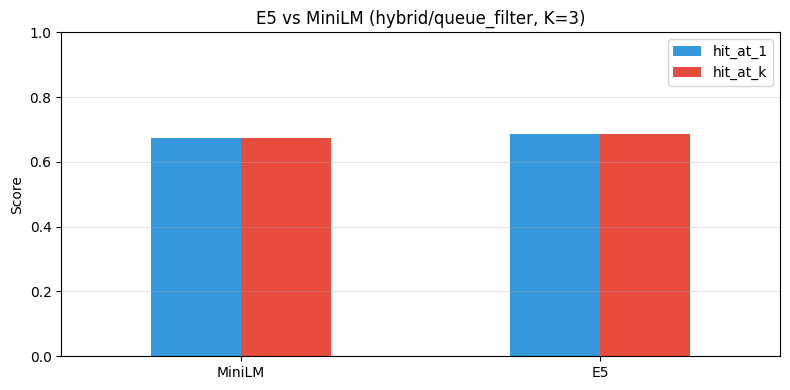

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
df_emb[["hit_at_1", "hit_at_k"]].plot.bar(ax=ax, rot=0, color=["#3498db", "#e74c3c"])
ax.set_ylabel("Score")
ax.set_title(f"E5 vs MiniLM ({best_method}/{best_filter}, K=3)")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Fenetre de tir : K optimal

### 4a. Collecte + calcul

In [31]:
# On teste K = 3, 5, 7, 10 sur la meilleure config (embedding + methode + filtre)
K_VALUES = [3, 5, 7, 10]

k_results = {}
for k in K_VALUES:
    print(f"  K={k} ...")
    if best_filter == "no_filter":
        k_results[k] = collect_results(
            search, test_cases_large, method=best_method, limit=k, collection=BEST_COLLECTION
        )
    else:
        field = best_filter.replace("_filter", "")
        k_results[k] = collect_with_case_filter(
            search, test_cases_large, method=best_method, limit=k,
            filter_field=field, collection=BEST_COLLECTION
        )

# Scores par K
k_rows = [{"K": k, "hit_at_1": hit_at_1(d), "hit_at_k": hit_at_k(d)} for k, d in k_results.items()]
df_k = pd.DataFrame(k_rows)
display(df_k.style.format({"hit_at_1": "{:.3f}", "hit_at_k": "{:.3f}"}))

BEST_K = int(df_k.loc[df_k["hit_at_k"].idxmax(), "K"])
print(f"\n>>> Meilleur K = {BEST_K}")

  K=3 ...
  K=5 ...
  K=7 ...
  K=10 ...


,K,hit_at_1,hit_at_k
0,3,0.674,0.674
1,5,0.677,0.677
2,7,0.688,0.688
3,10,0.677,0.677



>>> Meilleur K = 7


### 4b. Visualisation

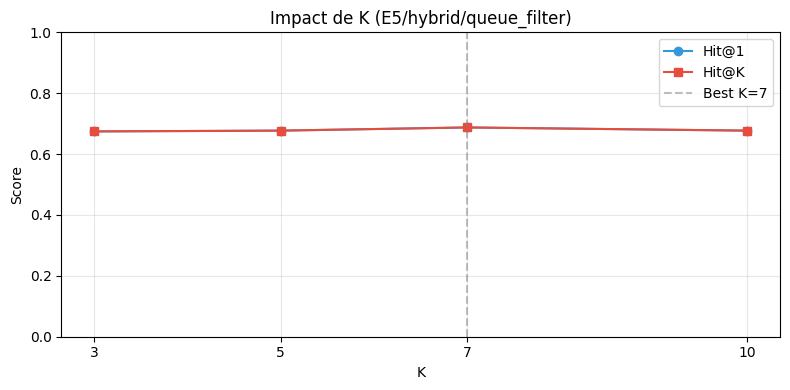

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_k["K"], df_k["hit_at_1"], "o-", label="Hit@1", color="#3498db")
ax.plot(df_k["K"], df_k["hit_at_k"], "s-", label="Hit@K", color="#e74c3c")
ax.axvline(BEST_K, ls="--", color="gray", alpha=0.5, label=f"Best K={BEST_K}")
ax.set_xlabel("K")
ax.set_ylabel("Score")
ax.set_title(f"Impact de K ({BEST_EMBEDDING}/{best_method}/{best_filter})")
ax.set_xticks(K_VALUES)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. RAGAS Baseline

Evaluation LLM sur la meilleure config identifiee (embedding + methode + filtre + K).

### 5a. Calcul

In [33]:
# Config finale
print(f"Config evaluee : {BEST_EMBEDDING} / {best_method} / {best_filter} / K={BEST_K}")
print(f"Collection : {BEST_COLLECTION}")
print(f"Test set : {len(test_cases_small)} samples (small)\n")

# Collecte avec la config optimale
if best_filter == "no_filter":
    baseline_data = collect_results(
        search, test_cases_small, method=best_method, limit=BEST_K, collection=BEST_COLLECTION
    )
else:
    field = best_filter.replace("_filter", "")
    baseline_data = collect_with_case_filter(
        search, test_cases_small, method=best_method, limit=BEST_K,
        filter_field=field, collection=BEST_COLLECTION
    )

# LLM juge
client = make_openrouter_client()
baseline_judge = make_judge("google/gemini-2.0-flash-001", client=client)

# Evaluation RAGAS
print(f"Evaluation RAGAS ({len(baseline_data)} samples) ...")
df_baseline = run_ragas(baseline_data, baseline_judge)

print("\n=== SCORES BASELINE ===")
for col in SCORE_COLS:
    print(f"  {col:<25} : {df_baseline[col].mean():.4f}")
print(f"  {'mean_score':<25} : {df_baseline[SCORE_COLS].mean(axis=1).mean():.4f}")

Config evaluee : E5 / hybrid / queue_filter / K=7
Collection : tickets_e5
Test set : 180 samples (small)

Evaluation RAGAS (180 samples) ...


Evaluating:   9%|▉         | 49/540 [03:05<34:12,  4.18s/it] Exception raised in Job[49]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    1 validation error for ContextRecallClassifications
  Invalid JSON: invalid escape at line 4 column 22 [type=json_invalid, input_value='{\n  "classifications": ...uted": 1\n    }\n  ]\n}', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid
</exception>
<completion>
    ChatCompletion(id='gen-1779038941-lL4F0H45M3zZ1DZeQadP', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "classifications": [\n    {\n      "statement": "\\\'name\\\', received your request to update the user interface color scheme for improved accessibility.",\n      "reason": "The context mentions a request to update the user interface color scheme to improve accessibility.",\n      "attributed": 1\n    },\n    {\n      "statement": "We apprecia


=== SCORES BASELINE ===
  context_precision         : 0.8872
  context_recall            : 0.8488
  context_entity_recall     : 0.4413
  mean_score                : 0.7251


### 5b. Segmentation par type/priority

In [34]:
# Ajout metadata
df_baseline["type"] = [tc["type"] for tc in test_cases_small]
df_baseline["priority"] = [tc["priority"] for tc in test_cases_small]

pivot_type = df_baseline.groupby("type")[SCORE_COLS].mean()
pivot_prio = df_baseline.groupby("priority")[SCORE_COLS].mean()

print("Par type :")
display(pivot_type.style.format("{:.4f}"))
print("\nPar priority :")
display(pivot_prio.style.format("{:.4f}"))

Par type :


,context_precision,context_recall,context_entity_recall
type,,,
Change,0.9184,0.8925,0.4763
Incident,0.8945,0.8404,0.4478
Problem,0.8785,0.8056,0.3059
Request,0.8573,0.8577,0.5351



Par priority :


,context_precision,context_recall,context_entity_recall
priority,,,
high,0.8817,0.8634,0.3928
low,0.8903,0.8087,0.5275
medium,0.8895,0.8736,0.4036


### 5c. Visualisation

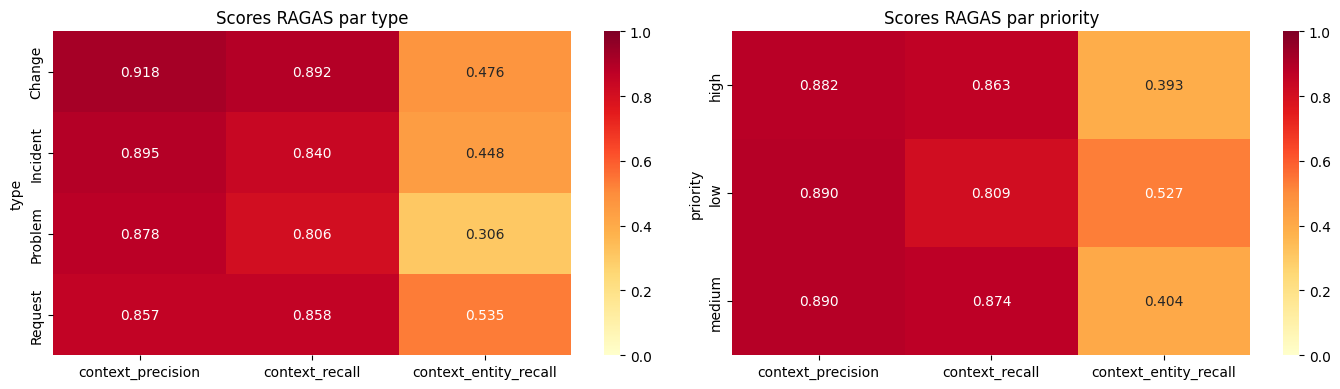

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(pivot_type, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Scores RAGAS par type")

sns.heatmap(pivot_prio, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Scores RAGAS par priority")

plt.tight_layout()
plt.show()

---
## 6. Reranking ColBERT

On sur-recupere K=20 resultats avec la meilleure config, puis ColBERT (`answerai-colbert-small-v1`) rescore les resultats cote serveur Qdrant.

### 6a. Calcul

In [36]:
# Reranking : hybrid_rerank (prefetch dense+sparse K=20 -> ColBERT rescore -> top-K)
print(f"=== RERANKING ColBERT (server-side) ===")
print(f"Pipeline : dense + BM25 (K=20) -> ColBERT rescore -> top-{BEST_K}")
print(f"Collection : {BEST_COLLECTION}\n")

if best_filter == "no_filter":
    reranked_data = collect_results(
        search, test_cases_small, method="hybrid_rerank", limit=BEST_K, collection=BEST_COLLECTION
    )
else:
    field = best_filter.replace("_filter", "")
    reranked_data = collect_with_case_filter(
        search, test_cases_small, method="hybrid_rerank", limit=BEST_K,
        filter_field=field, collection=BEST_COLLECTION
    )

print(f"  {len(reranked_data)} samples (reranked)")

# Hit@1 rapide
print(f"\n  Hit@1 baseline  : {hit_at_1(baseline_data):.3f}")
print(f"  Hit@1 reranked  : {hit_at_1(reranked_data):.3f}")

# RAGAS
print(f"\nEvaluation RAGAS reranked ...")
df_reranked = run_ragas(reranked_data, baseline_judge)

# Comparaison
rerank_summary = ragas_summary({"baseline": df_baseline, "reranked": df_reranked})
display(rerank_summary.style.format({c: "{:.4f}" for c in SCORE_COLS + ["mean_score"]}))

delta = rerank_summary.set_index("label").loc["reranked", "mean_score"] - rerank_summary.set_index("label").loc["baseline", "mean_score"]
print(f"\n>>> Delta reranking : {delta:+.4f} ({'ameliore' if delta > 0 else 'pas mieux'})")

=== RERANKING ColBERT (server-side) ===
Pipeline : dense + BM25 (K=20) -> ColBERT rescore -> top-7
Collection : tickets_e5

  180 samples (reranked)

  Hit@1 baseline  : 0.711
  Hit@1 reranked  : 0.822

Evaluation RAGAS reranked ...


Evaluating:   9%|▉         | 49/540 [03:13<33:20,  4.07s/it] Exception raised in Job[49]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    1 validation error for ContextRecallClassifications
  Invalid JSON: invalid escape at line 4 column 22 [type=json_invalid, input_value='{\n  "classifications": ...uted": 1\n    }\n  ]\n}', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid
</exception>
<completion>
    ChatCompletion(id='gen-1779041088-EzR5bVE4dRKNXufGazXg', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "classifications": [\n    {\n      "statement": "\\\'name\\\', received your request to update the user interface color scheme for improved accessibility.",\n      "reason": "The context mentions \\"Request to update the user interface color scheme to improve accessibility\\".",\n      "attributed": 1\n    },\n    {\n      "statement": "We appr

,label,context_precision,context_recall,context_entity_recall,mean_score
0,baseline,0.8872,0.8488,0.4413,0.7257
1,reranked,0.9143,0.8754,0.4813,0.7570



>>> Delta reranking : +0.0313 (ameliore)


### 6b. Visualisation

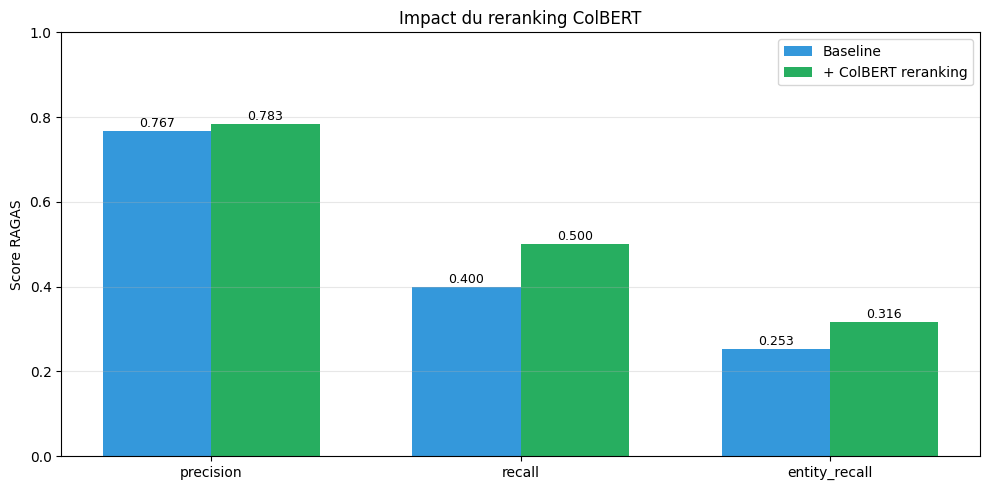

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SCORE_COLS))
width = 0.35

b_scores = [df_baseline[c].mean() for c in SCORE_COLS]
r_scores = [df_reranked[c].mean() for c in SCORE_COLS]

bars1 = ax.bar(x - width/2, b_scores, width, label="Baseline", color="#3498db")
bars2 = ax.bar(x + width/2, r_scores, width, label="+ ColBERT reranking", color="#27ae60")

ax.set_ylabel("Score RAGAS")
ax.set_title("Impact du reranking ColBERT")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("context_", "") for c in SCORE_COLS])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Robustesse du juge LLM

On compare les scores RAGAS entre 2 juges sur la meme config.

| Juge | Modele | Source |
|------|--------|--------|
| Gemini Flash | `google/gemini-2.0-flash-001` | reutilise depuis section 5 |
| GPT-5 Nano | `openai/gpt-5-nano` | nouveau |

### 7a. Calcul

In [37]:
# On prend la meilleure config de la section 6
if delta > 0:
    best_data = reranked_data
    best_df_gemini = df_reranked
    best_label = "reranked (ColBERT)"
else:
    best_data = baseline_data
    best_df_gemini = df_baseline
    best_label = "baseline"

print(f"Config evaluee : {best_label}")
print(f"  (Gemini Flash reutilise depuis section 6)\n")

# GPT-5 Nano comme 2e juge
nano_judge = make_judge("openai/gpt-5-nano", client=client)

print(f"=== EVALUATION GPT-5 Nano ({len(best_data)} samples) ===")
df_nano = run_ragas(best_data, nano_judge)

# Assemblage des 2 juges
judge_results = {"Gemini Flash": best_df_gemini, "GPT-5 Nano": df_nano}

print("\n=== DONE ===")

Config evaluee : reranked (ColBERT)
  (Gemini Flash reutilise depuis section 6)

=== EVALUATION GPT-5 Nano (180 samples) ===


Evaluating:   0%|          | 0/540 [00:00<?, ?it/s]Exception raised in Job[0]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    The output is incomplete due to a max_tokens length limit.
</exception>
<completion>
    ChatCompletion(id='gen-1779043331-TkWMveeTRVn8v038n98B', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "reason": "The context describes a healthcare provider experiencing hardware and software failures and requesting assistance, which supports the action of forwarding the issue to the technical', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning='**Assessing technical assistance context**\n\nThe context provides details about an issue and mentions there\'s a request for help. The answer states they\'ll forward it to the technical team and suggests contacting them for a timeline. It looks like the technical team has trie

KeyboardInterrupt: 

### 7b. Analyse

In [ ]:
# Tableau recapitulatif
df_judge_summary = ragas_summary(judge_results)
display(df_judge_summary.style.format({c: "{:.4f}" for c in SCORE_COLS + ["mean_score"]}))

# Correlations
df_corr = judge_correlations(judge_results)
print("\n=== CORRELATIONS INTER-JUGES ===")
display(df_corr.style.format({"pearson": "{:.3f}", "pearson_p": "{:.3f}", "spearman": "{:.3f}"}))

# Verdict
if len(df_corr) > 0:
    avg_p = df_corr["pearson"].mean()
    print(f"\nPearson moyen : {avg_p:.3f}")
    if avg_p > 0.7:
        print(">>> FORTE coherence : resultats robustes")
    elif avg_p > 0.5:
        print(">>> Coherence MODEREE : tendances fiables")
    elif avg_p > 0.3:
        print(">>> Coherence FAIBLE : rankings relatifs stables")
    else:
        print(">>> PAS de coherence : scores dependant du juge")

### 7c. Visualisation

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart scores par juge
ax = axes[0]
x = np.arange(len(SCORE_COLS))
width = 0.25
colors = ["#f39c12", "#3498db", "#2ecc71"]

for i, (_, row) in enumerate(df_judge_summary.iterrows()):
    scores = [row[c] for c in SCORE_COLS]
    bars = ax.bar(x + i * width - width, scores, width, label=row["label"], color=colors[i])
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

ax.set_ylabel("Score RAGAS")
ax.set_title("Scores par metrique et par juge")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("context_", "") for c in SCORE_COLS])
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Heatmap correlations
if len(df_corr) > 0:
    ax2 = axes[1]
    pivot_corr = df_corr.pivot(index="pair", columns="metric", values="pearson")
    sns.heatmap(pivot_corr, annot=True, fmt=".3f", cmap="RdYlGn", vmin=-1, vmax=1,
                ax=ax2, linewidths=0.5)
    ax2.set_title("Correlation Pearson entre juges")

plt.tight_layout()
plt.show()

---
## 8. Conclusions

| Parametre | Choix | Justification |
|-----------|-------|---------------|
| Methode | ? | Screening section 2 |
| Filtre | ? | Screening section 2 |
| Embedding | ? | Battle section 3 |
| K | ? | Fenetre section 4 |
| Reranking | ? | Section 6 |

(Remplir apres execution)